**OBJECTIVE 1: DATA COLLECTION**

CELL 1 — MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CELL 2 — IMPORT REQUIRED LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

**CELL 3 — LOAD DATASET FROM GOOGLE DRIVE**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/credit_card_fraud_synthetic.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


**CELL 4 — DISPLAY FIRST 5 ROWS**

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0


**CELL 5 — CHECK DATASET SHAPE**

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 8


**CELL 6 — CHECK COLUMN NAMES**

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class'], dtype='object')

**OBJECTIVE 2: DATA CLEANING & PREPROCESSING**

**CELL 7 — CHECK MISSING VALUES**

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
Amount,0
Class,0


**CELL 8 — REMOVE DUPLICATES**

In [ ]:
df = df.drop_duplicates()

print("Duplicates Removed")
print("New Shape :", df.shape)

Duplicates Removed
New Shape : (1000, 8)


**CELL 9 — CHECK DATA TYPES**

In [ ]:
df.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
Amount,float64
Class,int64


**CELL 10 — FILL NULL VALUES IF PRESENT**

In [ ]:
df = df.fillna(df.mean(numeric_only=True))
print("Missing Values Handled")

Missing Values Handled


**CELL 11 — BASIC DATA INFORMATION**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   int64  
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   Amount  1000 non-null   float64
 7   Class   1000 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


**OBJECTIVE 3: DESCRIPTIVE STATISTICS**

**CELL 12 — DESCRIPTIVE STATISTICS**

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,Amount,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,86194.539000,0.017610,0.069906,-0.022792,0.022354,-0.013218,2577.052080,0.018000
std,50008.474586,1.038301,1.035560,0.992346,0.978387,0.998908,1444.284318,0.133018
min,235.000000,-3.568205,-2.913672,-3.239438,-2.936162,-3.708797,25.890000,0.000000
25%,42052.250000,-0.646795,-0.594730,-0.693360,-0.624690,-0.711692,1358.502500,0.000000
50%,89361.500000,0.031403,0.089010,-0.008512,-0.000167,0.019587,2636.405000,0.000000
75%,127614.750000,0.742573,0.759734,0.666350,0.664478,0.686529,3849.640000,0.000000
max,172627.000000,3.174442,3.260491,2.750723,3.657702,2.840886,4998.710000,1.000000


**CELL 13 — AVERAGE TRANSACTION AMOUNT**

In [ ]:
avg_amount = df['Amount'].mean()

print("Average Transaction Amount :", avg_amount)

Average Transaction Amount : 2577.05208


**CELL 14 — FRAUD VS NORMAL COUNT**

In [ ]:
fraud_count = df['Class'].value_counts()

print(fraud_count)

Class
0    982
1     18
Name: count, dtype: int64


**CELL 15 — FRAUD PERCENTAGE**

In [ ]:
fraud_percent = (df['Class'].sum()/len(df))*100

print("Fraud Percentage :", fraud_percent)

Fraud Percentage : 1.7999999999999998


**OBJECTIVE 4: FRAUD BEHAVIOR ANALYSIS**

**CELL 16 — FRAUD VS NORMAL TRANSACTION ANALYSIS**

In [ ]:
fraud = df[df['Class']==1]
normal = df[df['Class']==0]

print("Fraud Transactions :", len(fraud))
print("Normal Transactions :", len(normal))

Fraud Transactions : 18
Normal Transactions : 982


**CELL 17 — FRAUD TRANSACTION STATISTICS**

In [ ]:
fraud['Amount'].describe()

,Amount
count,18.000000
mean,2381.920000
std,1134.369268
min,167.100000
25%,1479.822500
50%,2299.890000
75%,3481.960000
max,3948.910000


**CELL 18 — NORMAL TRANSACTION STATISTICS**

In [ ]:
normal['Amount'].describe()

,Amount
count,982.000000
mean,2580.628839
std,1449.558899
min,25.890000
25%,1357.707500
50%,2637.275000
75%,3858.762500
max,4998.710000


**OBJECTIVE 5: GROUP-BASED ANALYSIS**

**CELL 19 — AMOUNT VS FRAUD**

In [ ]:
df.groupby('Class')['Amount'].mean()

,Amount
Class,
0,2580.628839
1,2381.920000


**CELL 20 — TIME VS FRAUD**

In [ ]:
df.groupby('Class')['Time'].mean()

,Time
Class,
0,86270.832994
1,82032.277778


**CELL 21 — FEATURE PATTERN ANALYSIS**

In [ ]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,Amount
Class,,,,,,,
0,86270.832994,0.014982,0.072126,-0.01976,0.018787,-0.013382,2580.628839
1,82032.277778,0.160986,-0.051172,-0.18818,0.216924,-0.004255,2381.920000


**OBJECTIVE 6: RELATIONSHIP ANALYSIS**

**CELL 22 — CORRELATION MATRIX**

In [ ]:
correlation = df.corr()

correlation

,Time,V1,V2,V3,V4,V5,Amount,Class
Time,1.000000,0.003712,-0.014759,-0.025795,0.069737,-0.058153,0.054233,-0.011274
V1,0.003712,1.000000,0.007395,0.002214,-0.030697,0.088616,0.032516,0.018705
V2,-0.014759,0.007395,1.000000,0.061603,-0.016288,-0.035025,-0.026302,-0.015838
V3,-0.025795,0.002214,0.061603,1.000000,0.021182,0.035898,0.056290,-0.022576
V4,0.069737,-0.030697,-0.016288,0.021182,1.000000,-0.019725,-0.024785,0.026938
V5,-0.058153,0.088616,-0.035025,0.035898,-0.019725,1.000000,0.013353,0.001215
Amount,0.054233,0.032516,-0.026302,0.056290,-0.024785,0.013353,1.000000,-0.018301
Class,-0.011274,0.018705,-0.015838,-0.022576,0.026938,0.001215,-0.018301,1.000000


**CELL 23 — TOP CORRELATED FEATURES WITH CLASS**

In [ ]:
correlation['Class'].sort_values(ascending=False)

,Class
Class,1.000000
V4,0.026938
V1,0.018705
V5,0.001215
Time,-0.011274
V2,-0.015838
Amount,-0.018301
V3,-0.022576


**OBJECTIVE 7: DATA VISUALIZATION**

**CELL 24 — FRAUD DISTRIBUTION BAR CHART**

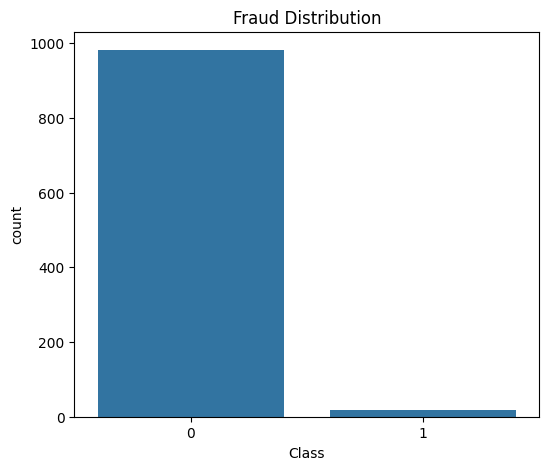

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='Class', data=df)

plt.title('Fraud Distribution')
plt.show()

**CELL 25 — TRANSACTION AMOUNT HISTOGRAM**

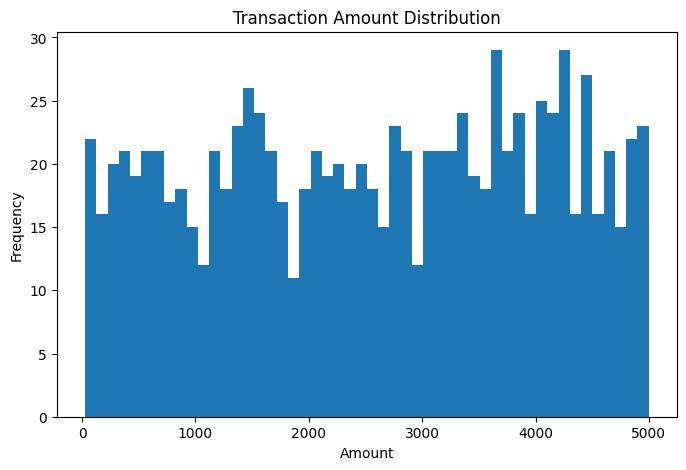

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Amount'], bins=50)

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

**CELL 26 — SCATTER PLOT**

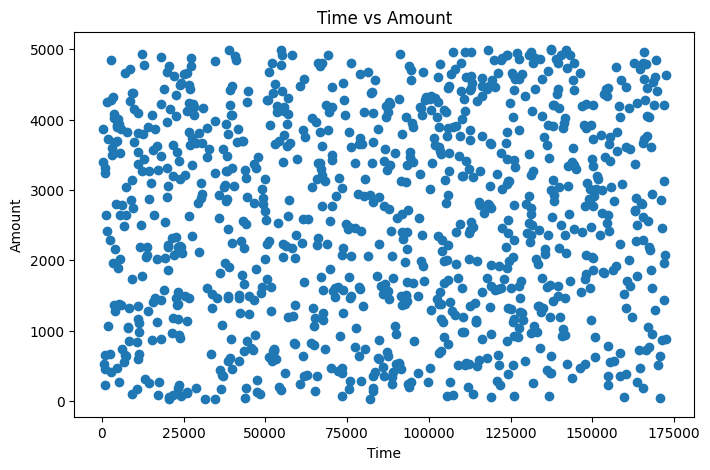

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Time'], df['Amount'])

plt.title('Time vs Amount')
plt.xlabel('Time')
plt.ylabel('Amount')

plt.show()

**CELL 27 — BOXPLOT FOR OUTLIER DETECTION**

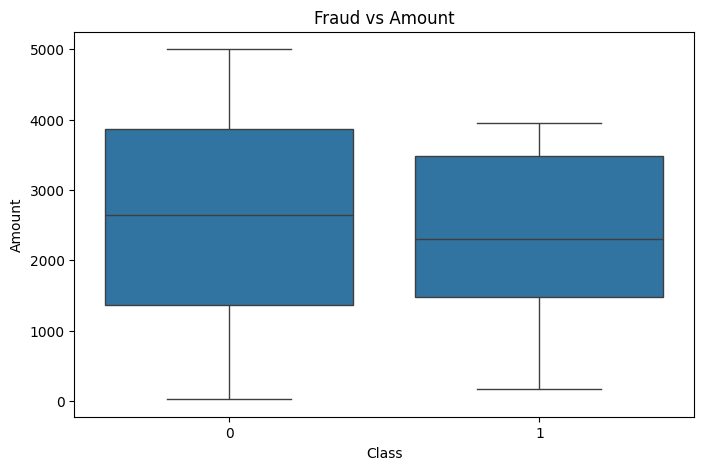

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Fraud vs Amount')

plt.show()

**CELL 28 — HEATMAP**

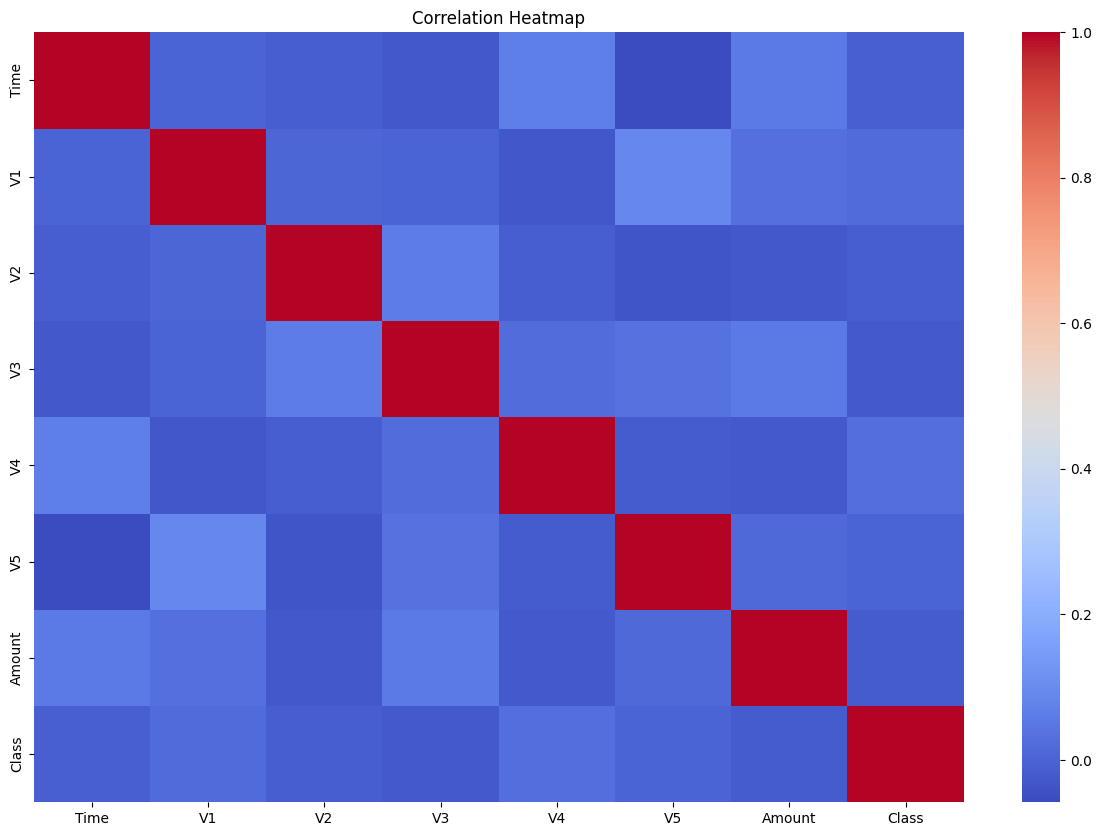

In [ ]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

**OBJECTIVE 8: RISK ANALYSIS**

**CELL 29 — CREATE RISK LEVELS**

In [ ]:
def risk_category(amount):

    if amount < 100:
        return 'Low Risk'

    elif amount < 1000:
        return 'Medium Risk'

    else:
        return 'High Risk'

df['Risk_Level'] = df['Amount'].apply(risk_category)

df[['Amount','Risk_Level']].head()

,Amount,Risk_Level
0,1600.89,High Risk
1,4191.85,High Risk
2,3271.32,High Risk
3,1377.51,High Risk
4,4838.72,High Risk


**CELL 30 — RISK LEVEL COUNT**

In [ ]:
df['Risk_Level'].value_counts()

,count
Risk_Level,
High Risk,811
Medium Risk,171
Low Risk,18


**CELL 31 — RISK LEVEL VISUALIZATION**

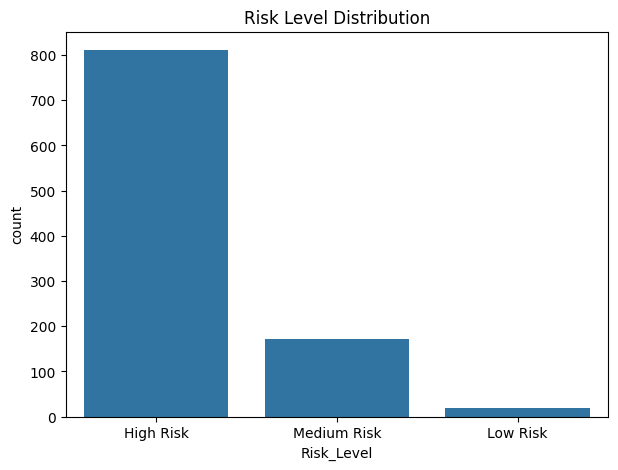

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='Risk_Level', data=df)

plt.title('Risk Level Distribution')

plt.show()

**OBJECTIVE 9: PREDICTIVE MODELING (LINEAR REGRESSION)**

**CELL 32 — DEFINE X AND Y VARIABLES**

In [ ]:
X = df[['Time']]
y = df['Amount']

**CELL 33 — TRAIN TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**CELL 34 — BUILD LINEAR REGRESSION MODEL**

In [ ]:
model = LinearRegression()

**CELL 35 — TRAIN MODEL**

In [ ]:
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


**CELL 36 — MAKE PREDICTIONS**

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2465.0849162  2519.93269242 2581.45241085 2489.22705422 2685.67807345
 2645.97909827 2755.6820027  2746.08396351 2630.86338125 2577.30036747]


**OBJECTIVE 10: MODEL EVALUATION**

**CELL 37 — R2 SCORE**

In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : -0.006739288518918141


**CELL 38 — ERROR METRICS**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)

Mean Absolute Error : 1213.997695593687
Mean Squared Error : 1956045.9695279659


**CELL 39 — RESIDUAL ANALYSIS**

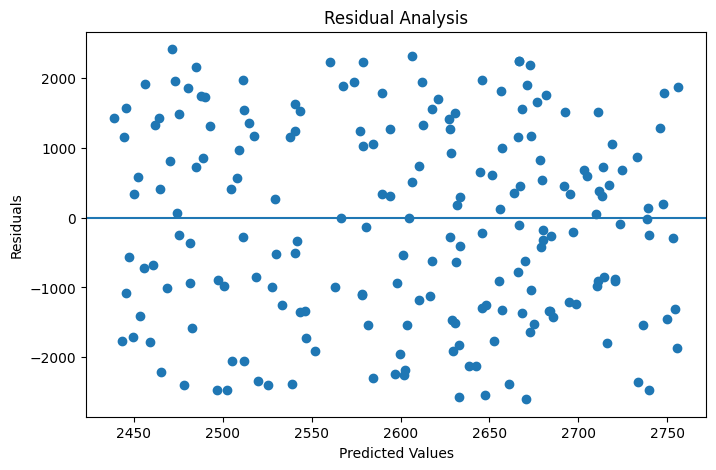

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.title('Residual Analysis')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.show()

**OBJECTIVE 11: DASHBOARD CREATION**

**CELL 40 — INTERACTIVE FRAUD DISTRIBUTION**

In [ ]:
fig = px.histogram(
    df,
    x='Class',
    title='Fraud Distribution'
)

fig.show()

**CELL 41 — INTERACTIVE AMOUNT TREND**

In [ ]:
fig = px.line(
    df.head(1000),
    x='Time',
    y='Amount',
    title='Transaction Amount Trend'
)

fig.show()

**CELL 42 — INTERACTIVE FRAUD COMPARISON**

In [ ]:
fig = px.box(
    df,
    x='Class',
    y='Amount',
    title='Fraud vs Amount'
)

fig.show()

**CELL 43 — INTERACTIVE CORRELATION HEATMAP**

In [ ]:
fig = px.imshow(
    correlation,
    title='Correlation Heatmap'
)

fig.show()

**CELL 44 — RISK LEVEL DASHBOARD**

In [ ]:
fig = px.pie(
    df,
    names='Risk_Level',
    title='Risk Level Distribution'
)

fig.show()